# Resource Breakdown per Group (Pie Charts)

For each major group: what resources they LOSE (red) vs GAIN (blue), shown as pie charts.

In [1]:
import json, re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.dpi'] = 150

GEMINI_DIR = Path("../data/llm_results/gemini_v18")
sample = pd.read_csv("../data/perseus_works_wikidata_sample.tsv", sep="\t")

# Load all rules
all_rows = []
for fp in GEMINI_DIR.glob("tlg*.json"):
    with open(fp) as f: data = json.load(f)
    fid = data.get("_file_id", fp.stem)
    meta = sample[sample["file_id"] == fid]
    if len(meta) == 0: continue
    m = meta.iloc[0]
    for r in data.get("extracted_rules", []):
        if not isinstance(r, dict): continue
        all_rows.append({"author": m["perseus_author"], "group": str(r.get("group","")).strip(),
            "group_category": str(r.get("group_category","")).strip(),
            "resource_category": str(r.get("resource_category","")).strip(),
            "rule_category": str(r.get("rule_category","")).strip(),
            "direction": str(r.get("directionality","")).strip().upper(),
            "author_impact_date": m["author_impact_date"], "file_id": fid, "n_pages": m["n_pages"]})

df = pd.DataFrame(all_rows)

# Harmonize groups
def harmonize_who(v):
    s = str(v).strip().lower()
    if re.search(r"wom[ae]n|female|wife|maiden|widow|mother|daughter", s): return "Women"
    if re.search(r"slav|enslav|servil|bondage|unfree|helot", s): return "Slaves"
    if re.search(r"non.?citizen|metic|foreigner|resident alien|stranger|exile|immigrant", s): return "Non-citizens"
    if re.search(r"citizen|full citiz", s): return "Citizens"
    if re.search(r"poor|propertyless|destitut|landless", s): return "The poor"
    if re.search(r"wealth|rich|affluent|propert", s): return "The wealthy"
    if re.search(r"noble|aristocrat|highborn|royal|king|prince", s): return "Nobility"
    if re.search(r"common|lowborn|base.?born|non.?noble|peasant", s): return "Commoners"
    if re.search(r"young|youth|child|minor|infant|boy|girl", s): return "Young/Children"
    if re.search(r"elder|old\b|elderly|aged|senior", s): return "Elders"
    if re.search(r"barbarian|ethnic|non.?greek", s): return "Barbarians"
    if re.search(r"soldier|warrior|military|veteran", s): return "Soldiers"
    if re.search(r"priest|priestess|clergy", s): return "Priests"
    if re.search(r"^men$|^male|husband|adult men|free men", s): return "Men"
    if re.search(r"disabled|sick|ill\b|blind|deaf", s): return "Disabled/Sick"
    return None

df["who_h"] = df["group"].apply(harmonize_who)
df = df[df["who_h"].notna() & df["resource_category"].notna() & (df["resource_category"] != "")]
df = df[pd.to_numeric(df["author_impact_date"], errors="coerce").notna()]
df["year"] = df["author_impact_date"].astype(int)

def period(y):
    if y <= -480: return "Archaic"
    elif y <= -360: return "Classical Athens"
    elif y <= -165: return "Late Classical"
    elif y <= 105: return "Hellenistic"
    else: return "High Roman"

df["period"] = df["year"].apply(period)
dedup = df.drop_duplicates(subset=["author", "who_h", "resource_category", "direction"])
print(f"Loaded {len(df):,} raw rules, {len(dedup):,} deduplicated, from {df['file_id'].nunique()} works")

Loaded 3,636 raw rules, 1,438 deduplicated, from 85 works


## Pie charts for selected groups

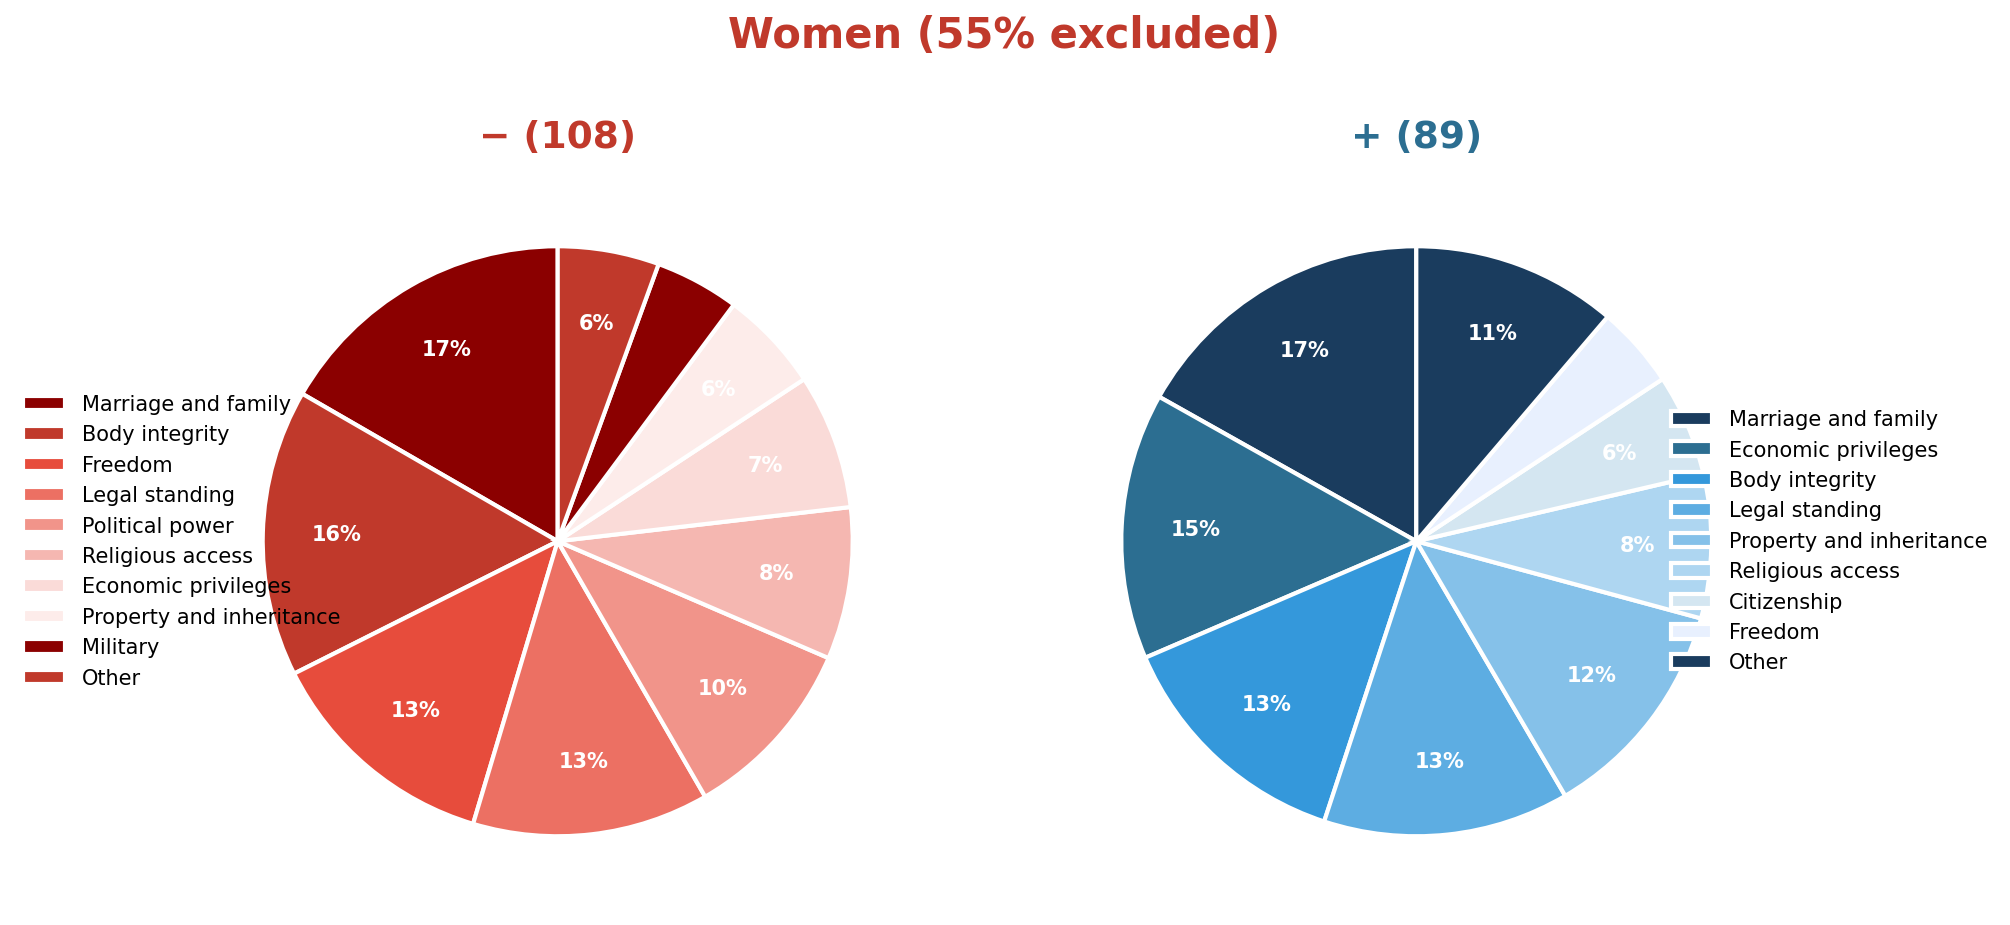

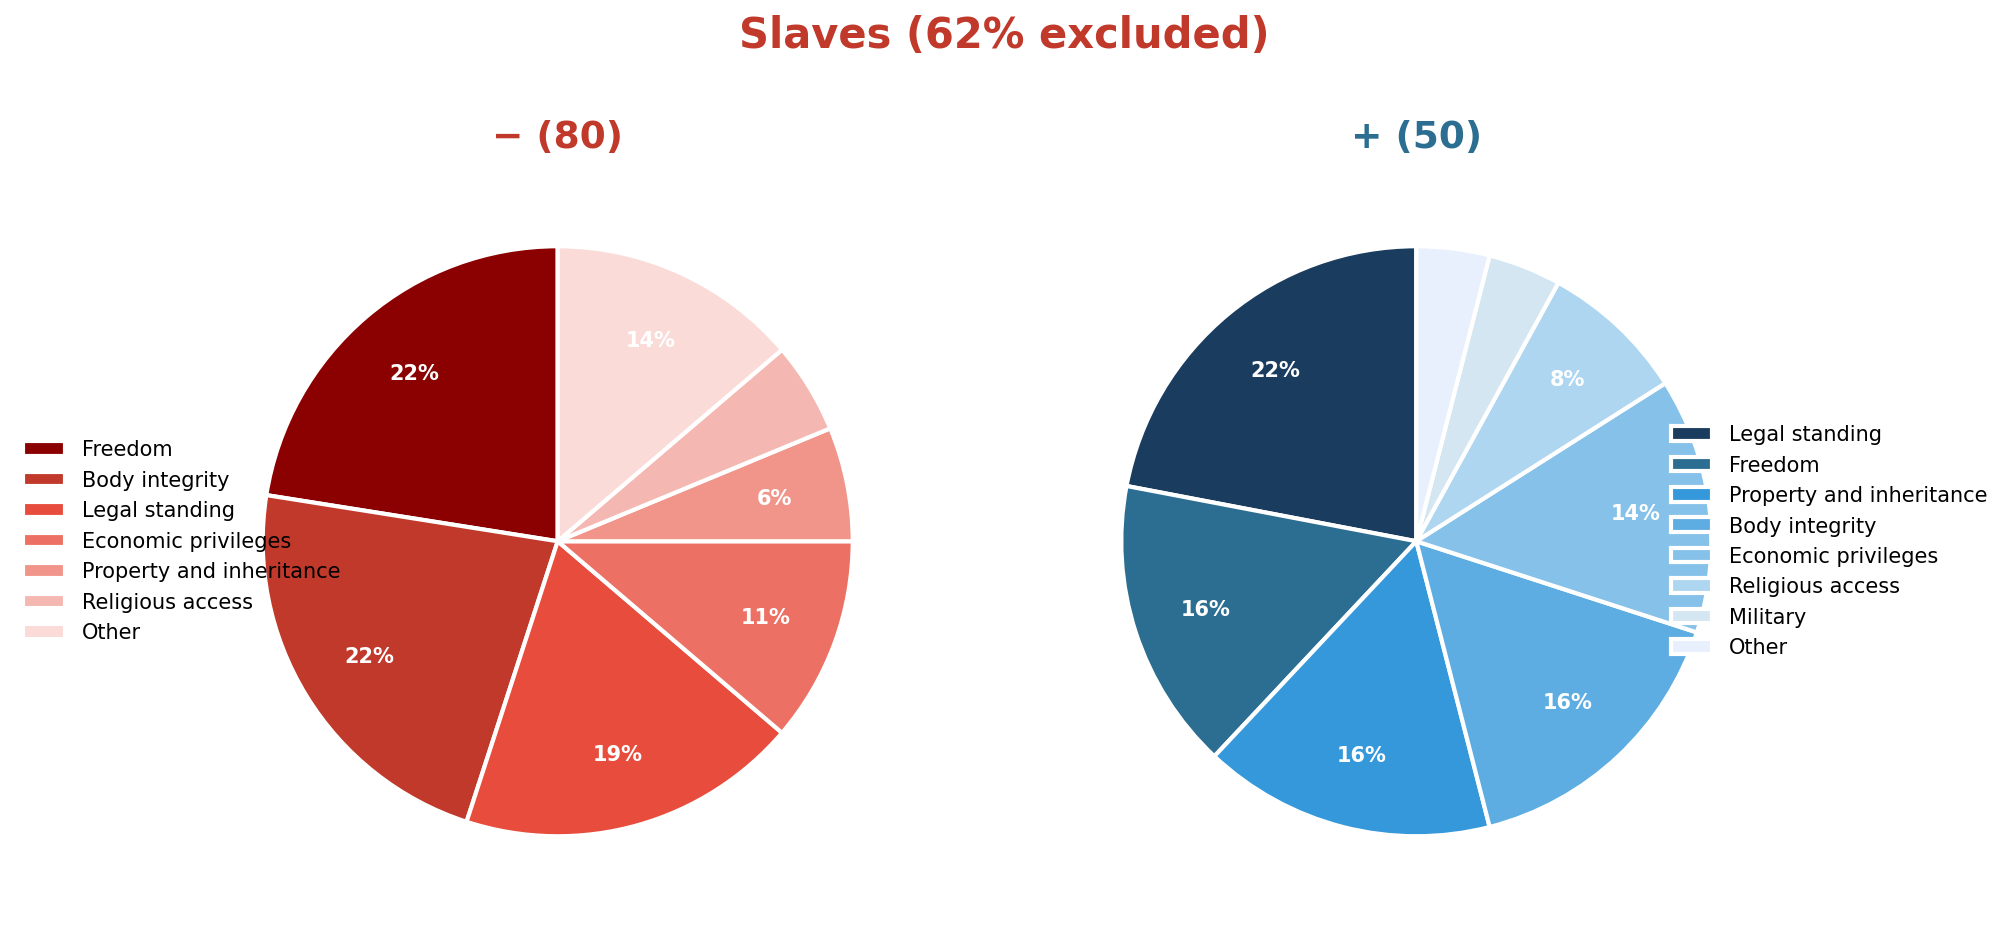

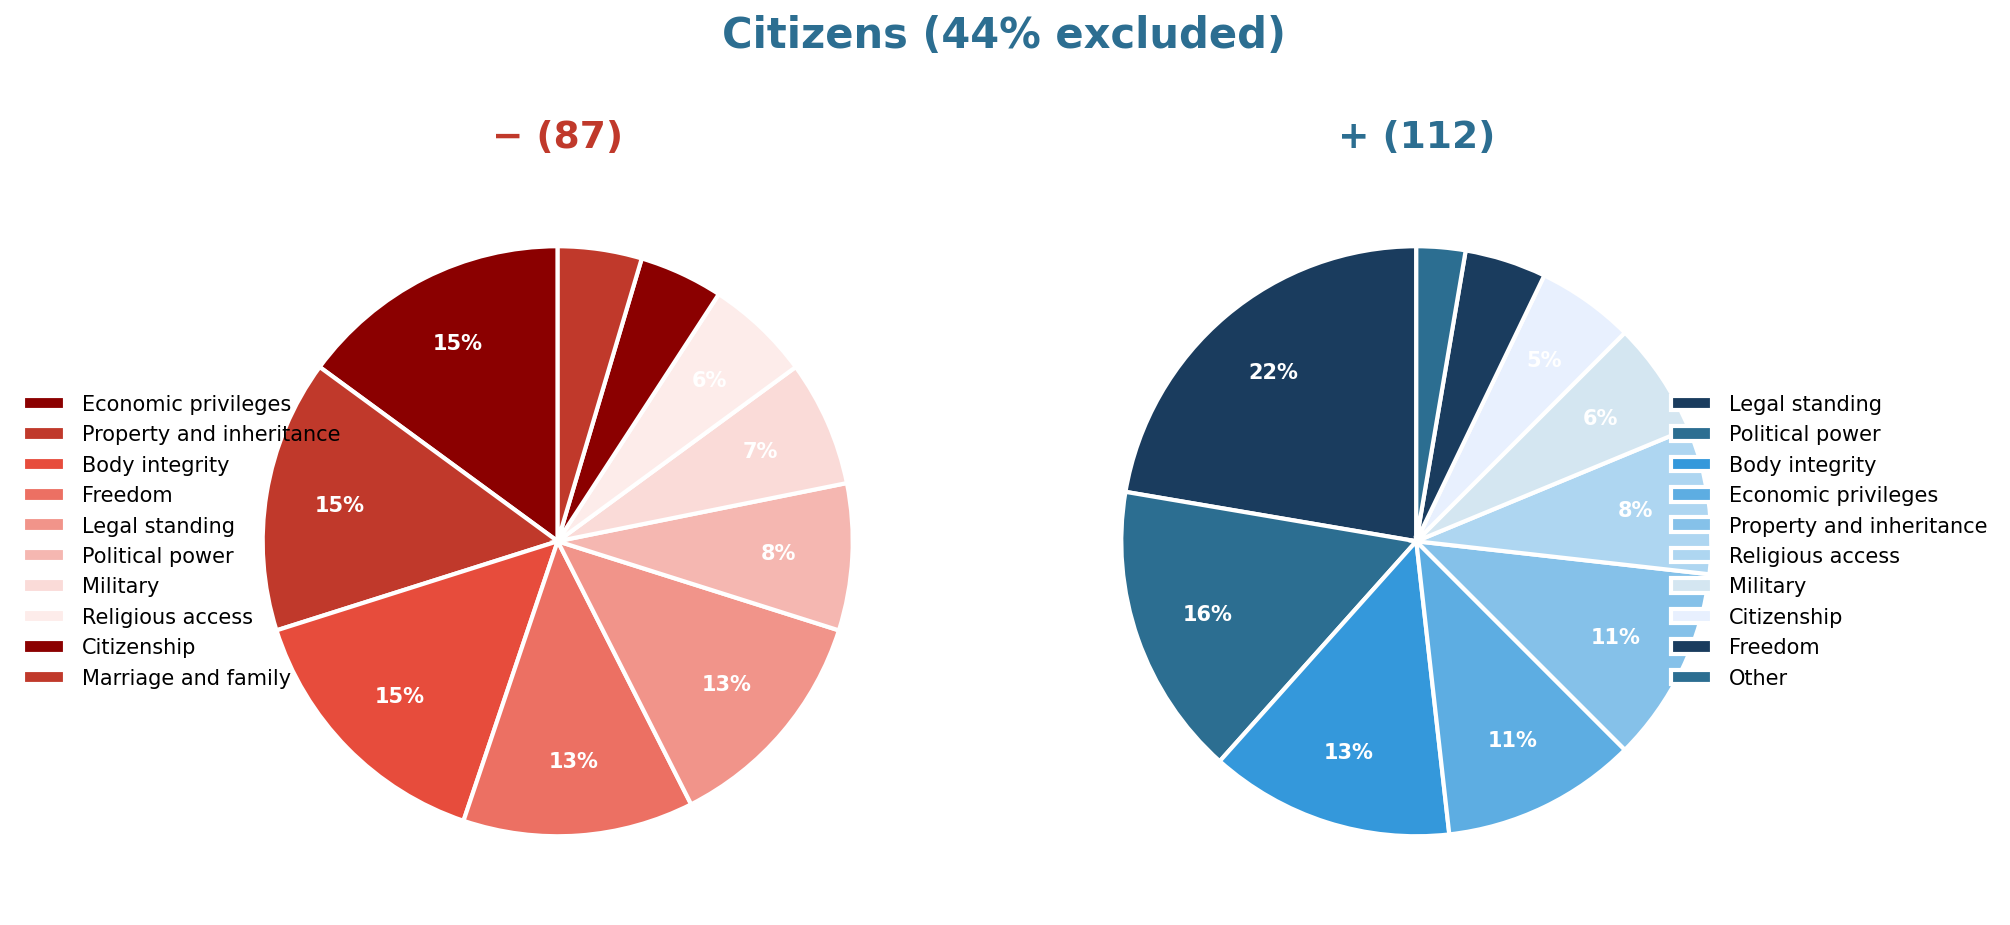

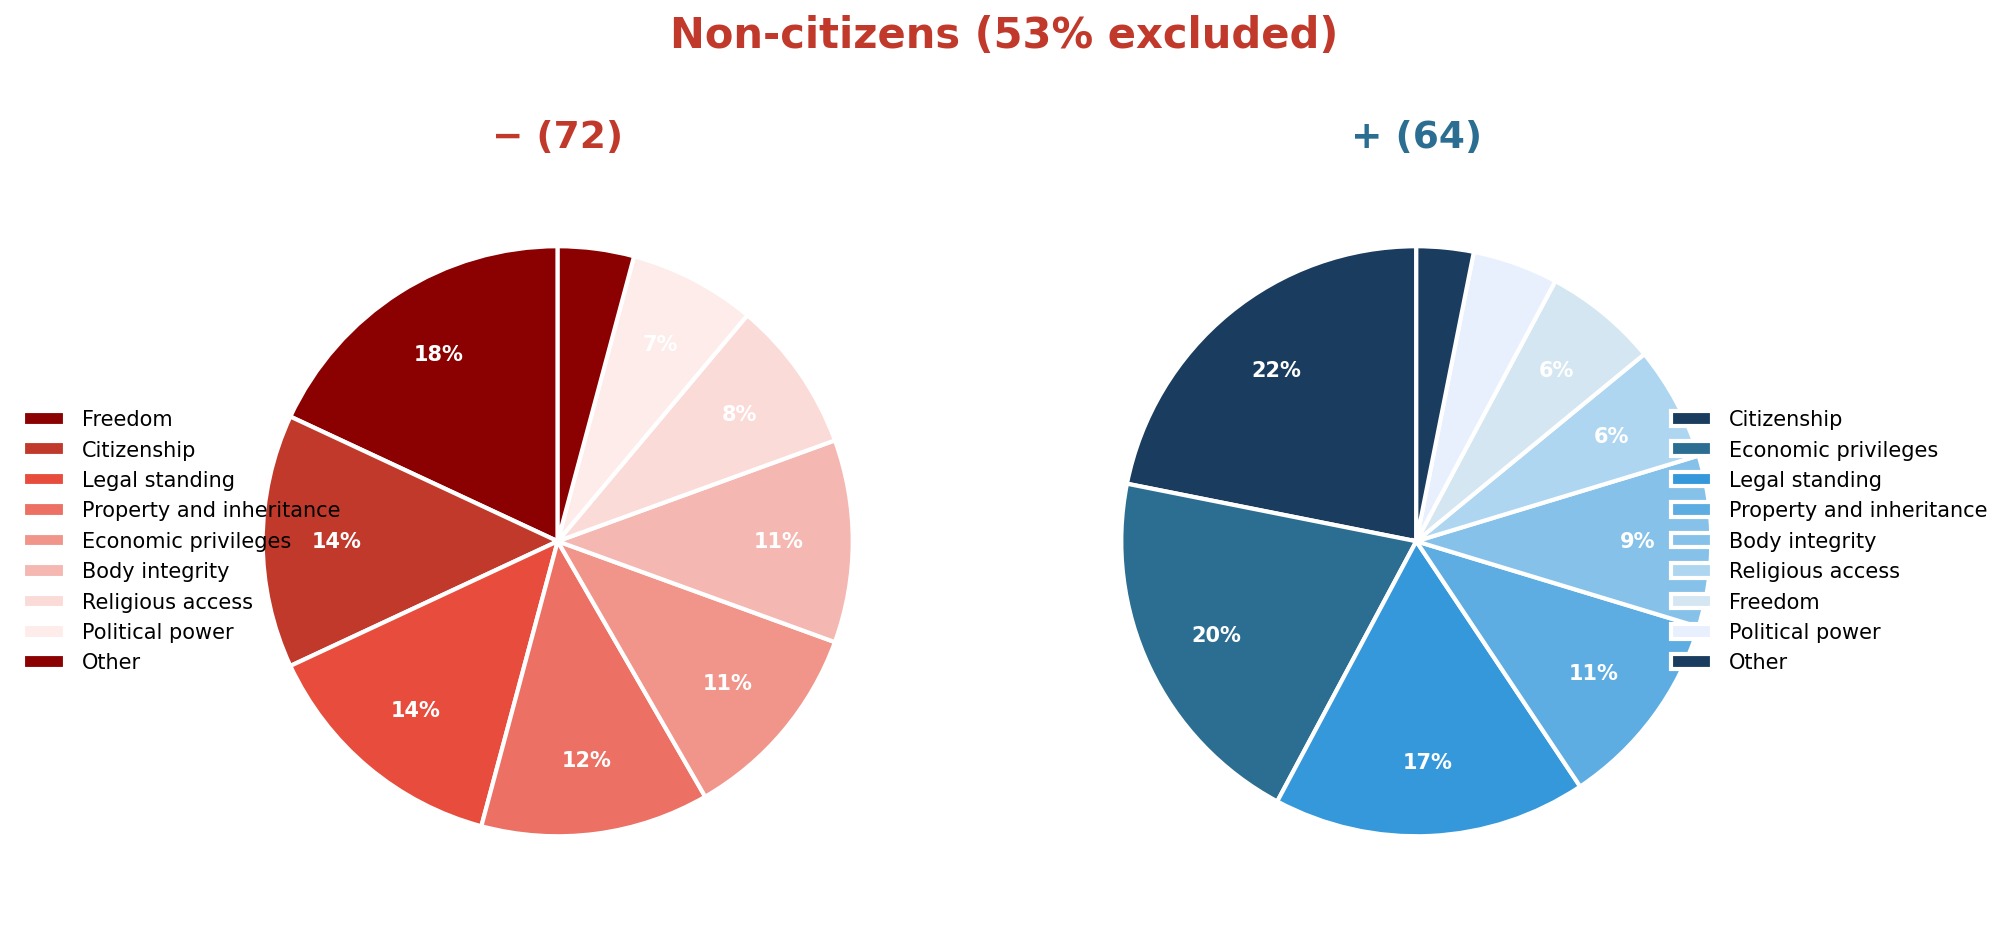

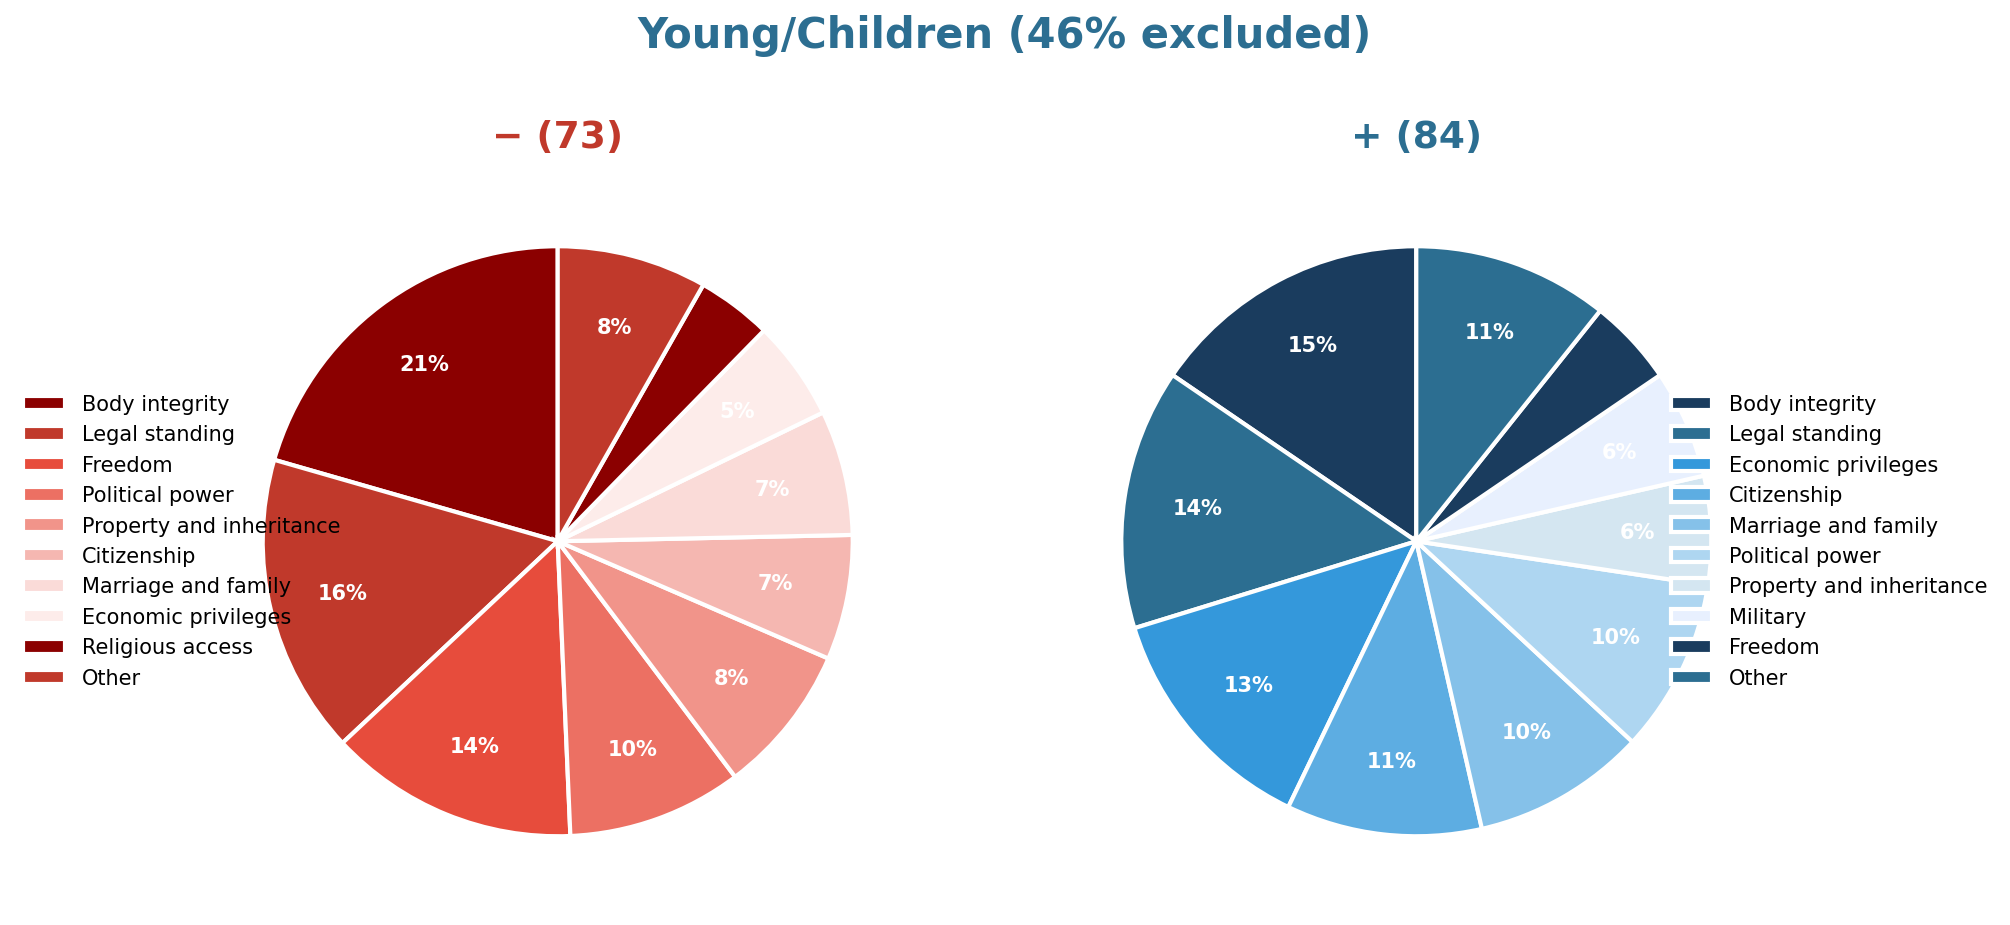

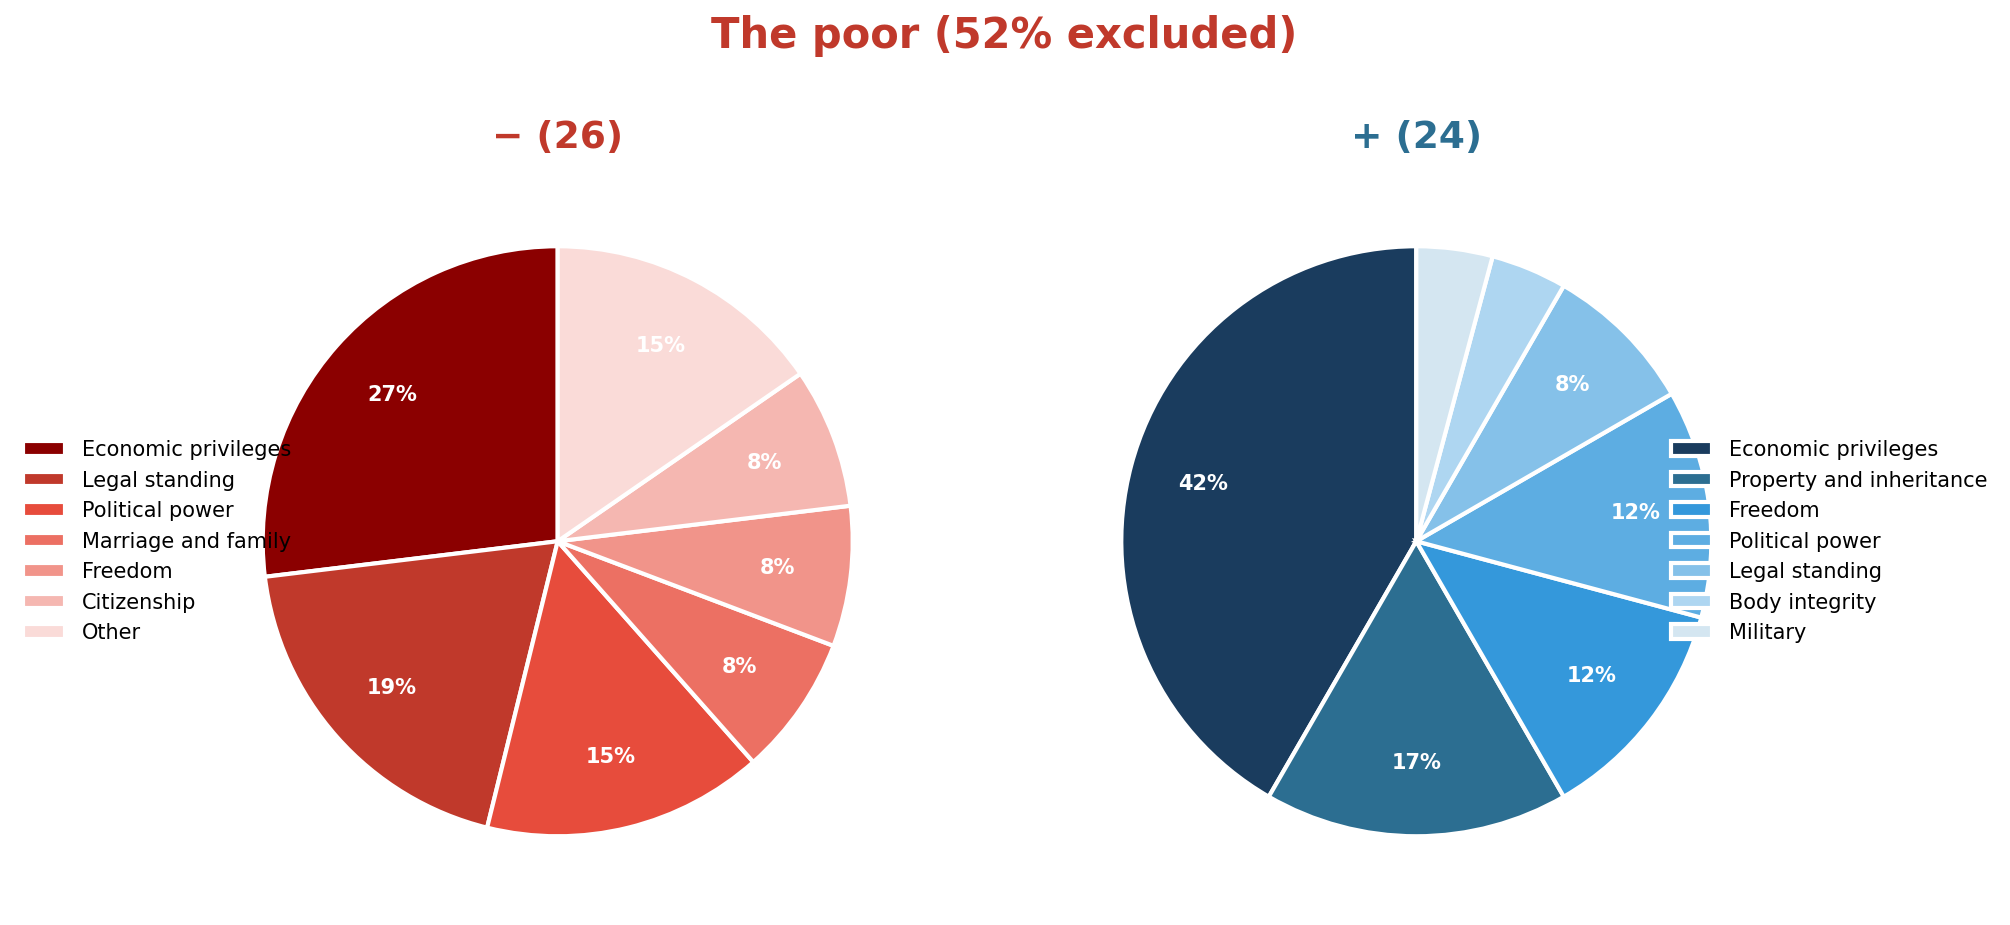

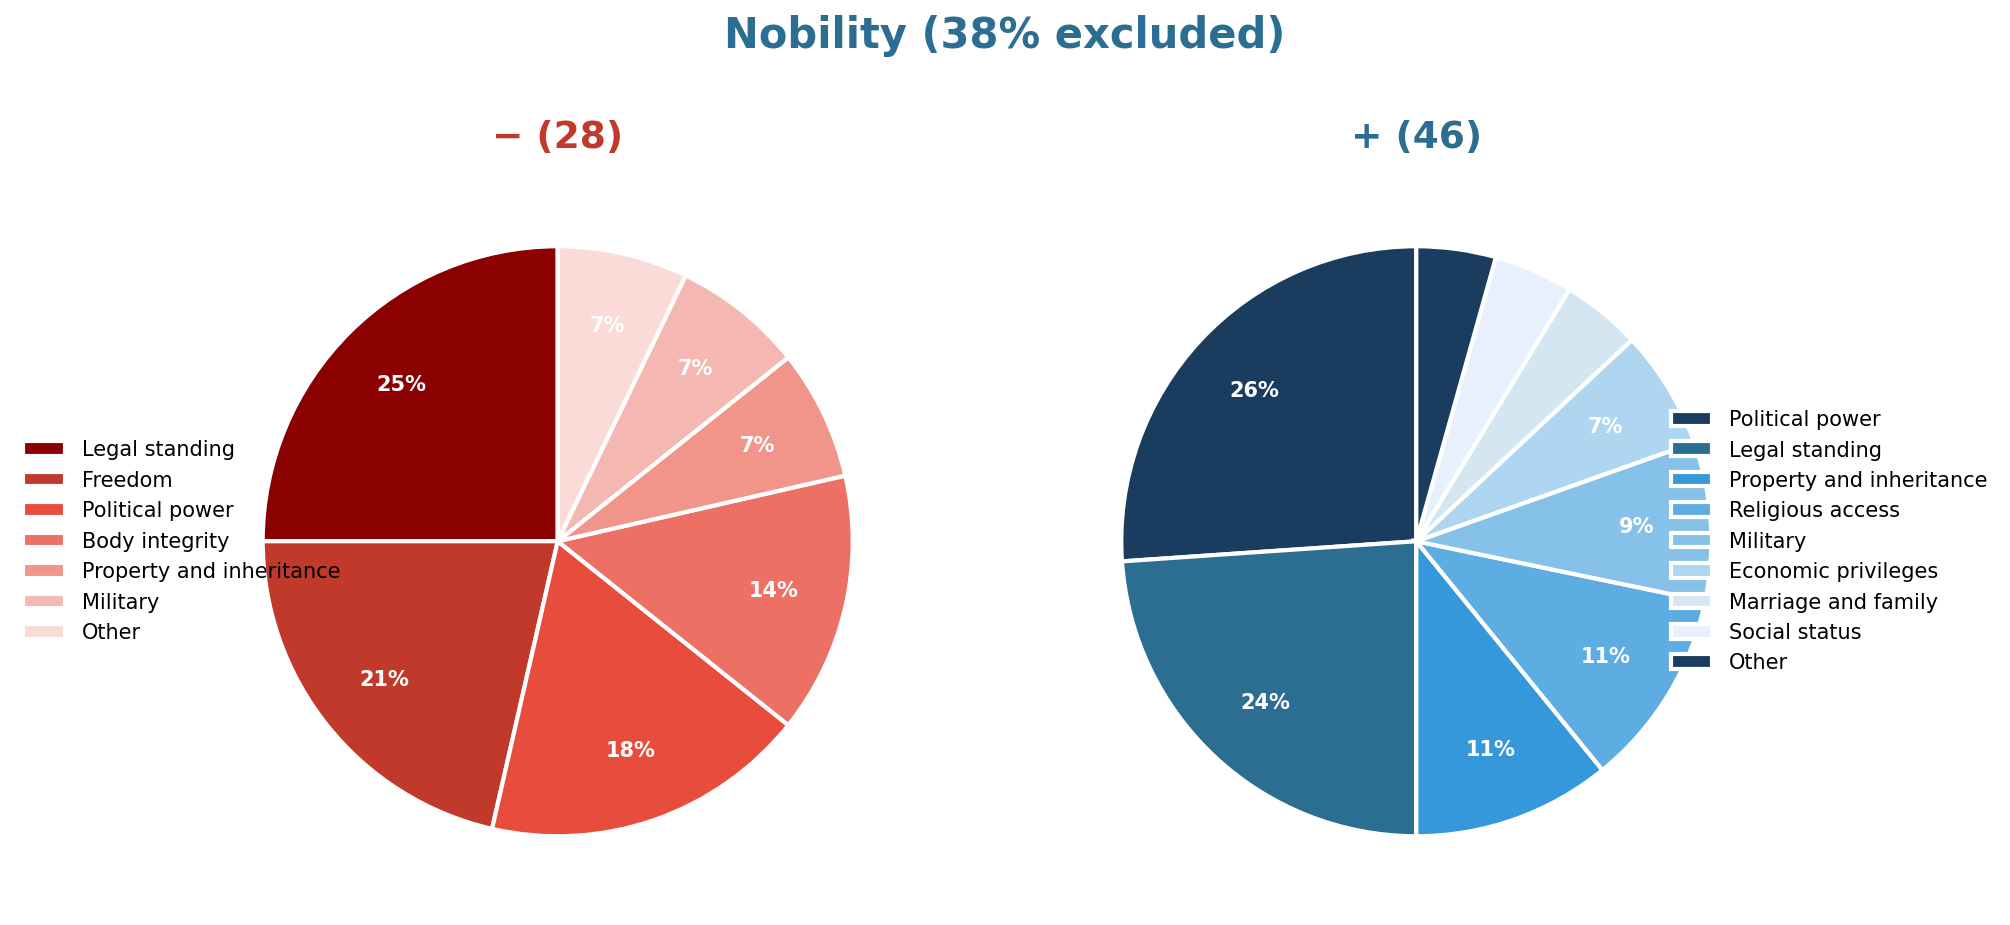

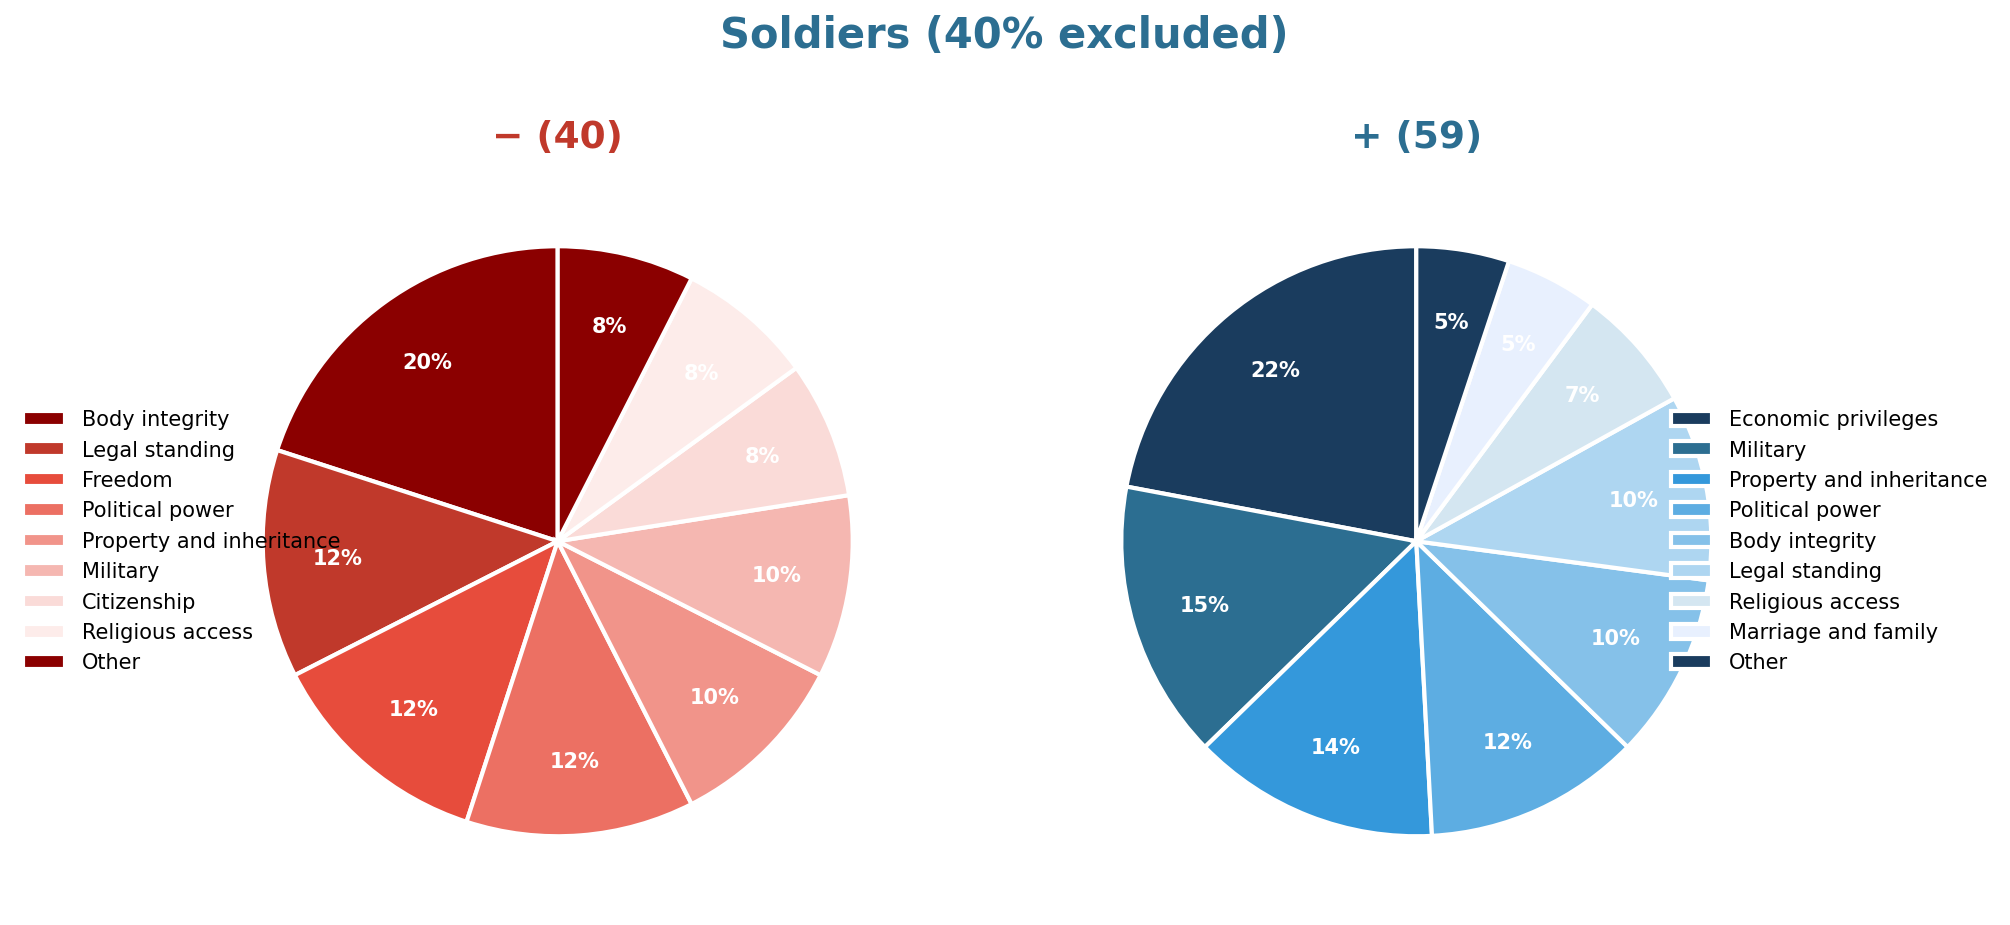

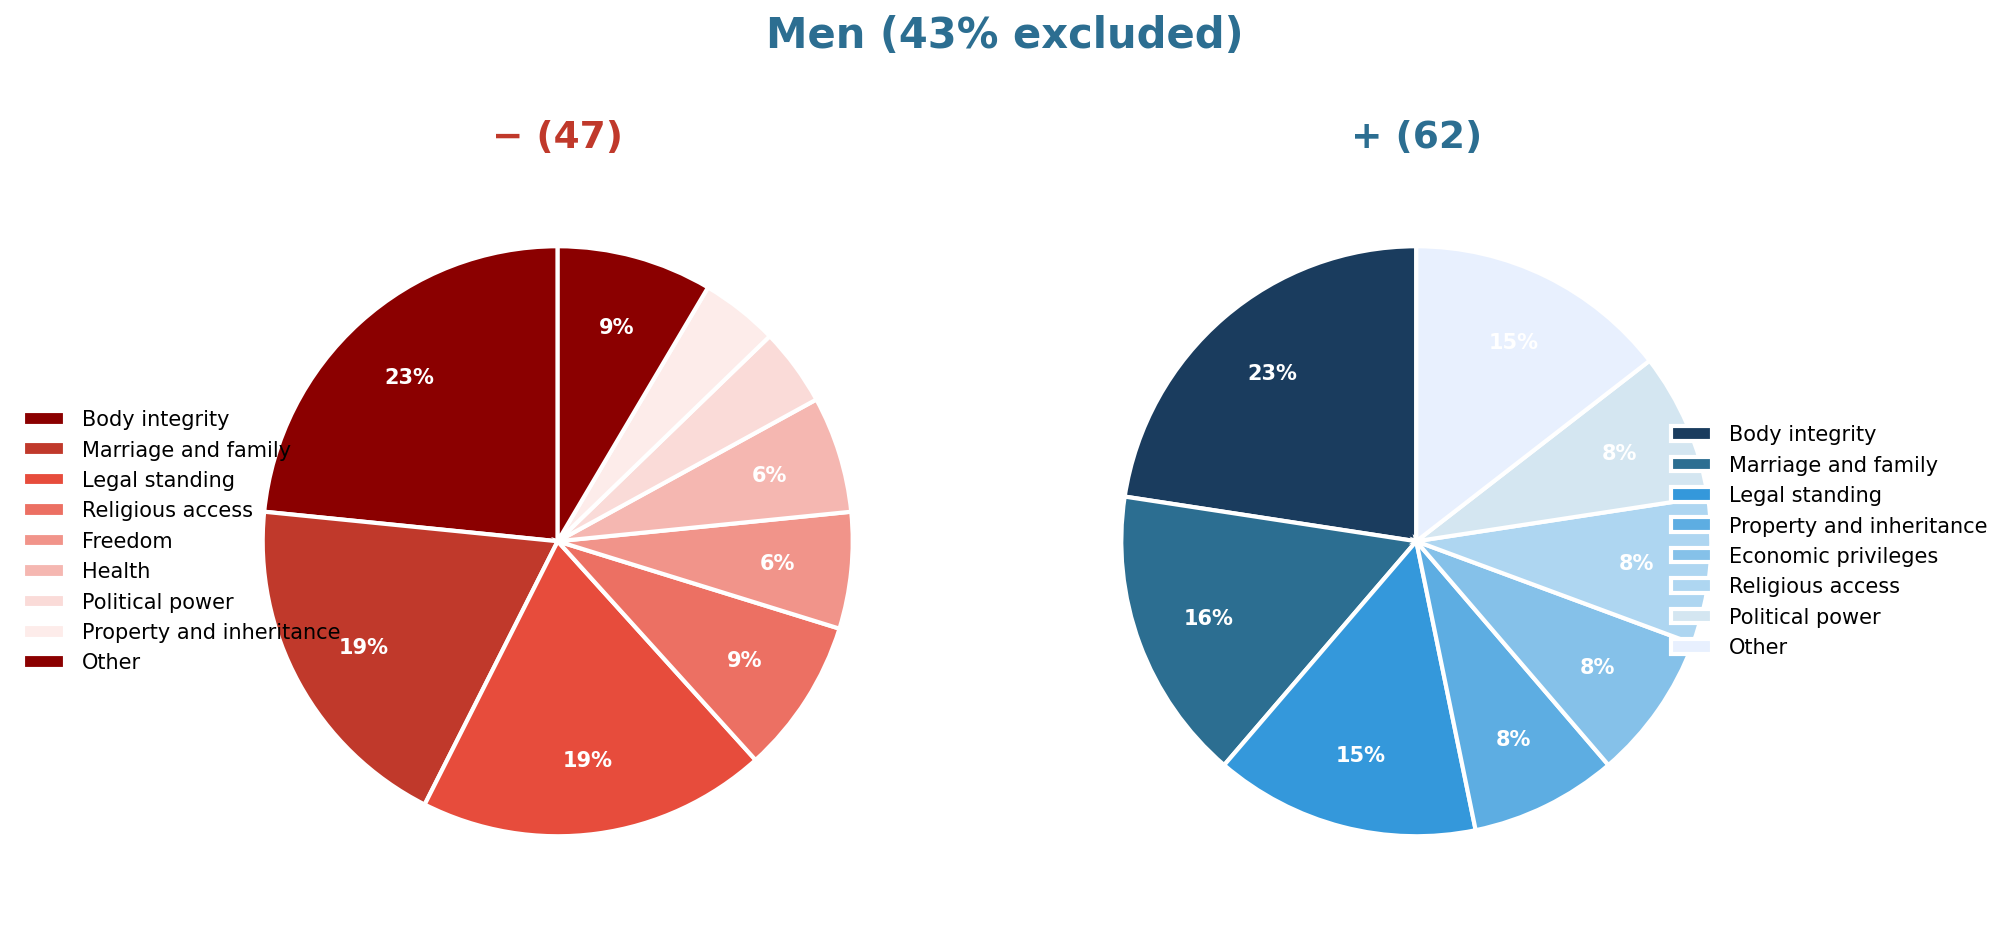

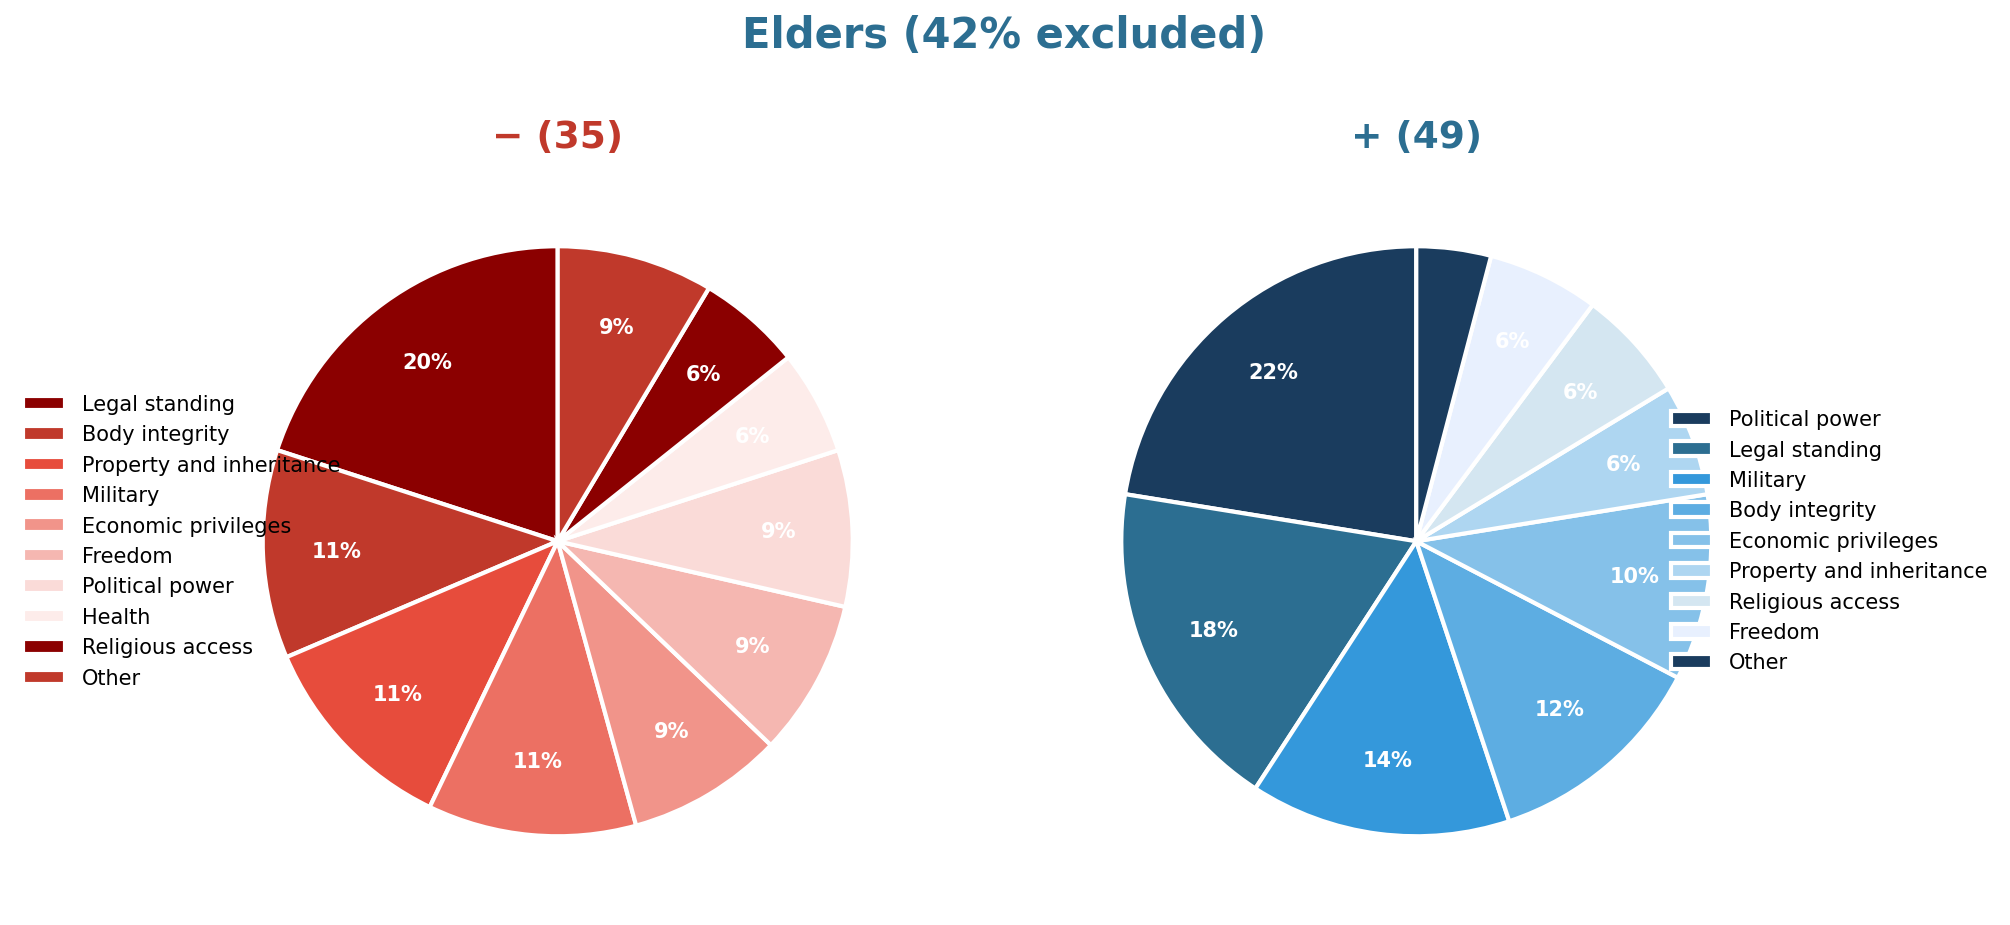

In [2]:
reds = ["#8b0000","#c0392b","#e74c3c","#ec7063","#f1948a","#f5b7b1","#fadbd8","#fdecea"]
blues = ["#1a3c5e","#2c6e91","#3498db","#5dade2","#85c1e9","#aed6f1","#d4e6f1","#e8f0fe"]

for who in ["Women", "Slaves", "Citizens", "Non-citizens", "Young/Children", "The poor", "Nobility", "Soldiers", "Men", "Elders"]:
    who_data = dedup[dedup["who_h"]==who]
    n_less = len(who_data[who_data["direction"]=="LESS"])
    n_more = len(who_data[who_data["direction"]=="MORE"])
    if n_less+n_more < 5: continue

    fig, (ax1,ax2) = plt.subplots(1,2,figsize=(14,6))
    ratio = n_less/(n_less+n_more)*100

    for ax,sub,n,cols,ttl,side in [(ax1,who_data[who_data["direction"]=="LESS"],n_less,reds,f"\u2212 ({n_less})","left"),
                                    (ax2,who_data[who_data["direction"]=="MORE"],n_more,blues,f"+ ({n_more})","right")]:
        counts = sub["resource_category"].value_counts()
        if len(counts)==0:
            ax.text(0.5,0.5,"No data",ha="center",va="center",fontsize=16,color="#ccc",transform=ax.transAxes)
        else:
            thr = 0.04*max(n,1); main = counts[counts>=thr]; other = counts[counts<thr].sum()
            if other>0: main = pd.concat([main, pd.Series({"Other": other})])
            w,t,at = ax.pie(main.values, labels=None, autopct=lambda p: f"{p:.0f}%" if p>5 else "", colors=cols[:len(main)],
                startangle=90, pctdistance=0.75, wedgeprops={"edgecolor":"white","linewidth":2})
            for a in at: a.set_fontsize(10); a.set_fontweight("600"); a.set_color("white")
            loc = "center left" if side=="left" else "center right"
            bbox = (-0.25,0.5) if side=="left" else (1.3,0.5)
            ax.legend(main.index, loc=loc, bbox_to_anchor=bbox, fontsize=10, frameon=False)
        ax.set_title(ttl, fontsize=18, fontweight="700", color="#c0392b" if "\u2212" in ttl else "#2c6e91", pad=12)

    fig.suptitle(f"{who} ({ratio:.0f}% excluded)", fontsize=20, fontweight="700",
                 color="#c0392b" if ratio>50 else "#2c6e91", y=1.02)
    plt.tight_layout(); plt.show()